## How well do jobs and skills pay for Data Analysts?
### Methodology
1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

In [2]:
# importing libraries
import pandas as pd 
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns 

# loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# # data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [9]:
df_DA_US  = df[(df['job_country'] == 'United States')]

In [ ]:
top6 = df['job_title'].value_counts().head(6).index.to_list()

In [16]:
df_T6 = df_DA_US[df_DA_US['job_title_short'].isin(top6)].dropna(subset= 'salary_year_avg')

In [ ]:
df_T6_2 = df_T6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

Index(['Senior Data Scientist', 'Senior Data Engineer', 'Data Scientist',
       'Data Engineer', 'Senior Data Analyst', 'Data Analyst'],
      dtype='str', name='job_title_short')

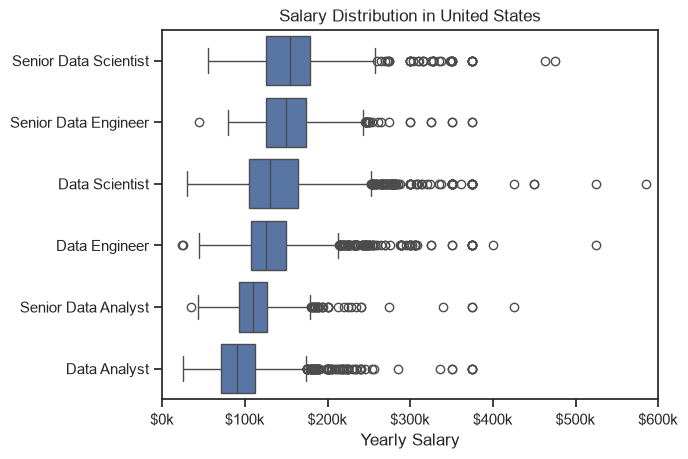

In [45]:
sns.boxplot(data=df_T6, x='salary_year_avg', y = 'job_title_short', order=df_T6_2)
sns.set_theme(style='ticks')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}k'))
plt.title('Salary Distribution in United States')
plt.xlim(0,600000)
plt.xlabel('Yearly Salary')
plt.ylabel('')
plt.show()

## Investigate Median Salary vs Skills for Data Analysts

In [28]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()

df_DA_US = df_DA_US.dropna(subset = 'salary_year_avg')

df_DA_US = df_DA_US.explode('job_skills')

df_DA_Top_Pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(ascending=False,by='median')
df_DA_Top_Pay = df_DA_Top_Pay.head(10)


df_DA_Top_Skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(ascending=False,by='count')
df_DA_Top_Skills = df_DA_Top_Skills.head(10).sort_values(by='median',ascending=False)
df_DA_Top_Skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


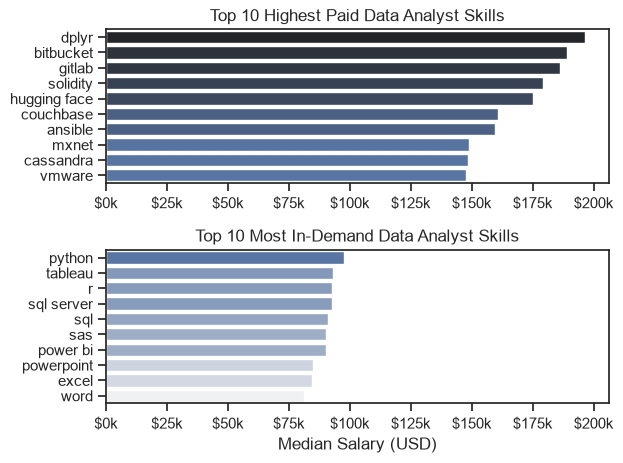

In [31]:
fig, ax = plt.subplots(2,1)
sns.set_theme(style='ticks')

#  Data Analyst Skills having Highest pay
# df_DA_Top_Pay[::-1].plot(kind ='barh', y = 'median', ax = ax[0], legend=False)
sns.barplot(data=df_DA_Top_Pay,x='median',y=df_DA_Top_Pay.index, hue='median', palette='dark:b_r', ax=ax[0])
ax[0].legend_.remove()
ax[0].set_title('Top 10 Highest Paid Data Analyst Skills')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
# ax[0].legend().set_visible(False)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos : f'${int(x/1000)}k'))


# Most In-Demand Data Analyst Skills
# df_DA_Skills[::-1].plot(kind ='barh', y = 'median', ax = ax[1])
sns.barplot(data=df_DA_Top_Skills,x='median',y=df_DA_Top_Skills.index, hue='median', palette='light:b', ax=ax[1])
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Data Analyst Skills')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_ylabel('')
ax[1].legend().set_visible(False)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos : f'${int(x/1000)}k'))
plt.tight_layout()